In [2]:
# ONE-CELL: prepare processed images + masks, then train a small UNet
# Run in Colab or Jupyter. In Colab it will prompt upload if no images found.
# NOTE: training on ~20 images will overfit; this uses augmentation and a small model.

import os, shutil, zipfile, random
from pathlib import Path
from PIL import Image
import numpy as np
import cv2
from tqdm import tqdm

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

# ---- Config ----
RAW_IMG_DIR = "my_images"          # collected raw uploads
PROCESSED_DIR = Path("processed_20")
MASK_DIR = Path("processed_masks")
PRED_DIR = Path("preds")
MODEL_SAVE_PATH = "best_model.pth"

IMG_SIZE = 256
BATCH_SIZE = 2
NUM_EPOCHS = 12
LR = 1e-3
VAL_SPLIT = 0.2
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 20251029
random.seed(SEED)
torch.manual_seed(SEED)

# create dirs
Path(RAW_IMG_DIR).mkdir(exist_ok=True)
PROCESSED_DIR.mkdir(exist_ok=True)
MASK_DIR.mkdir(exist_ok=True)
PRED_DIR.mkdir(exist_ok=True)

# detect Colab
try:
    from google.colab import files as colab_files
    IN_COLAB = True
except Exception:
    IN_COLAB = False

# ---- helper functions ----
def find_images_anywhere(root='.'):
    exts = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')
    found = []
    for r, _, files in os.walk(root):
        for f in files:
            if f.lower().endswith(exts):
                # ignore outputs we create
                if any(skip in r for skip in ['processed_20', 'processed_masks', 'preds', '__pycache__']):
                    continue
                found.append(os.path.join(r, f))
    return found

def move_images_to_folder(img_paths, dest_folder):
    Path(dest_folder).mkdir(parents=True, exist_ok=True)
    moved = []
    for p in img_paths:
        src = Path(p)
        dest = Path(dest_folder) / src.name
        # avoid overwrite
        if dest.exists():
            base = dest.stem
            suf = dest.suffix
            i = 1
            while (Path(dest_folder) / f"{base}_{i}{suf}").exists():
                i += 1
            dest = Path(dest_folder) / f"{base}_{i}{suf}"
        shutil.copy(src, dest)
        moved.append(dest)
    return [Path(p) for p in moved]

def create_otsu_mask(pil_img):
    arr = np.array(pil_img)
    gray = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return Image.fromarray(mask)

# ---- Step A: gather raw images (upload if needed) ----
found = find_images_anywhere('.')
found = [p for p in found if not Path(p).match('*/processed_20/*') and not Path(p).match('*/processed_masks/*')]
if len(found) == 0:
    if IN_COLAB:
        print("No images found. Please upload your image files (select your 20 images) in the dialog.")
        uploaded = colab_files.upload()
        if len(uploaded) == 0:
            raise SystemExit("No files uploaded. Re-run and upload images.")
        # update found list
        found = find_images_anywhere('.')
    else:
        raise SystemExit("No images found. Place your images in the notebook folder or upload and re-run.")

# copy images into RAW_IMG_DIR
moved = move_images_to_folder(found, RAW_IMG_DIR)
print(f"Collected {len(moved)} images into '{RAW_IMG_DIR}/' (sample):")
for p in moved[:20]:
    print(" -", p.name)

# ---- Step B: create processed images (deterministic resize) ----
print("\nCreating processed images in", PROCESSED_DIR)
for p in moved:
    try:
        img = Image.open(p).convert("RGB")
        img_resized = img.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
        outp = PROCESSED_DIR / f"proc_{p.name}"
        img_resized.save(outp)
    except Exception as e:
        print("Failed to process", p, ":", e)

proc_list = sorted([p for p in PROCESSED_DIR.iterdir() if p.suffix.lower() in ('.jpg','.jpeg','.png')])
print(f"Created {len(proc_list)} processed images.")

# ---- Step C: create masks (Otsu) if none exist ----
mask_list = sorted([p for p in MASK_DIR.iterdir() if p.suffix.lower() in ('.jpg','.jpeg','.png')])
if len(mask_list) == 0:
    print("No masks found in processed_masks/. Generating masks with Otsu from processed images.")
    for p in proc_list:
        try:
            img = Image.open(p).convert("RGB")
            mask = create_otsu_mask(img)
            outm = MASK_DIR / f"mask_{p.stem.replace('proc_','')}.png"
            mask.save(outm)
        except Exception as e:
            print("Failed to create mask for", p, ":", e)
    mask_list = sorted([p for p in MASK_DIR.iterdir() if p.suffix.lower() in ('.jpg','.jpeg','.png')])
print(f"Mask images available: {len(mask_list)}")

# ---- Pairing (by basename after removing prefixes) ----
def key_from_path(p):
    s = p.stem.lower()
    s = s.replace("proc_", "").replace("mask_", "")
    s = s.replace("processed_", "").replace("image_","")
    return s

proc_map = { key_from_path(p): p for p in proc_list }
mask_map = { key_from_path(p): p for p in mask_list }
common_keys = sorted(set(proc_map.keys()) & set(mask_map.keys()))

# try fuzzy matching if none
if len(common_keys) == 0:
    from difflib import SequenceMatcher
    pairs = []
    for kp, pv in proc_map.items():
        best_k = None; best_score = 0
        for km in mask_map.keys():
            score = SequenceMatcher(None, kp, km).ratio()
            if score > best_score:
                best_score = score; best_k = km
        if best_score > 0.5:
            pairs.append((kp, best_k))
    # build paired maps
    proc_map = {a: proc_map[a] for a,b in pairs}
    mask_map = {a: mask_map[b] for a,b in pairs}
    common_keys = sorted(set(proc_map.keys()) & set(mask_map.keys()))

image_list = [str(proc_map[k]) for k in common_keys]
mask_list = [str(mask_map[k]) for k in common_keys]

print(f"Paired {len(image_list)} image(s) and mask(s) for training.")
if len(image_list) == 0:
    print("Processed images:", [p.name for p in proc_list])
    print("Masks:", [p.name for p in mask_list])
    raise SystemExit("No pairs could be matched. Rename masks to correspond to processed images and re-run.")

# ---- Dataset + UNet (light) ----
class SegDataset(Dataset):
    def __init__(self, imgs, masks, img_size=IMG_SIZE, augment=False):
        self.imgs = imgs; self.masks = masks; self.img_size = img_size; self.augment = augment
        self.to_tensor = T.ToTensor()
    def __len__(self): return len(self.imgs)
    def __getitem__(self, idx):
        img = Image.open(self.imgs[idx]).convert('RGB').resize((self.img_size,self.img_size), Image.BILINEAR)
        mask = Image.open(self.masks[idx]).convert('L').resize((self.img_size,self.img_size), Image.NEAREST)
        # augment geometric transforms synchronously
        if self.augment:
            if random.random() < 0.5:
                img = img.transpose(Image.FLIP_LEFT_RIGHT); mask = mask.transpose(Image.FLIP_LEFT_RIGHT)
            angle = random.uniform(-15,15)
            img = img.rotate(angle, resample=Image.BILINEAR); mask = mask.rotate(angle, resample=Image.NEAREST)
            img = T.ColorJitter(0.15,0.15,0.15)(img)
        img_t = self.to_tensor(img)
        mask_t = T.ToTensor()(mask)
        mask_t = (mask_t > 0.5).float()
        return img_t, mask_t

# small UNet
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
        )
    def forward(self,x): return self.net(x)

class Down(nn.Module):
    def __init__(self,in_c,out_c): super().__init__(); self.net = nn.Sequential(nn.MaxPool2d(2), DoubleConv(in_c,out_c))
    def forward(self,x): return self.net(x)

class Up(nn.Module):
    def __init__(self,in_c,out_c):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_c,out_c,2,stride=2)
        self.conv = DoubleConv(in_c,out_c)
    def forward(self,x1,x2):
        x1 = self.up(x1)
        diffY = x2.size()[2]-x1.size()[2]; diffX = x2.size()[3]-x1.size()[3]
        x1 = F.pad(x1, [diffX//2, diffX-diffX//2, diffY//2, diffY-diffY//2])
        x = torch.cat([x2,x1], dim=1); return self.conv(x)

class UNetSmall(nn.Module):
    def __init__(self, n_channels=3, n_classes=1, base=16):
        super().__init__()
        self.inc = DoubleConv(n_channels, base)
        self.down1 = Down(base, base*2)
        self.down2 = Down(base*2, base*4)
        self.up1 = Up(base*4, base*2)
        self.up2 = Up(base*2, base)
        self.outc = nn.Conv2d(base, n_classes, 1)
    def forward(self,x):
        x1 = self.inc(x); x2 = self.down1(x1); x3 = self.down2(x2)
        x = self.up1(x3, x2); x = self.up2(x, x1); x = self.outc(x); return x

# ---- prepare dataloaders ----
N = len(image_list)
idxs = list(range(N)); random.shuffle(idxs)
split = int(N*(1-VAL_SPLIT))
if split == 0: split = max(1, int(N*0.8))
train_idx = idxs[:split]; val_idx = idxs[split:]
train_imgs = [image_list[i] for i in train_idx]; train_masks = [mask_list[i] for i in train_idx]
val_imgs = [image_list[i] for i in val_idx]; val_masks = [mask_list[i] for i in val_idx]

train_ds = SegDataset(train_imgs, train_masks, augment=True)
val_ds = SegDataset(val_imgs, val_masks, augment=False)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"\nTraining samples: {len(train_ds)}, Validation samples: {len(val_ds)}")

# ---- training utilities ----
def dice_coeff_tensor(pred, target, eps=1e-6):
    pred = pred.view(pred.size(0), -1)
    target = target.view(target.size(0), -1)
    inter = (pred * target).sum(dim=1)
    union = pred.sum(dim=1) + target.sum(dim=1)
    return ((2*inter + eps)/(union + eps)).mean().item()

class DiceLoss(nn.Module):
    def __init__(self, eps=1e-6): super().__init__(); self.eps = eps
    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        probs = probs.view(probs.size(0), -1)
        targets = targets.view(targets.size(0), -1)
        inter = (probs * targets).sum(dim=1)
        union = probs.sum(dim=1) + targets.sum(dim=1)
        return (1 - ((2*inter + self.eps)/(union + self.eps))).mean()

# ---- model, optimizer ----
model = UNetSmall(n_channels=3, n_classes=1, base=16).to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=LR)
bce = nn.BCEWithLogitsLoss()
dice = DiceLoss()
best_val = -1.0

# ---- TRAIN LOOP ----
for epoch in range(1, NUM_EPOCHS+1):
    model.train()
    train_loss = 0.0
    for imgs, masks in train_loader:
        imgs = imgs.to(DEVICE); masks = masks.to(DEVICE)
        logits = model(imgs)
        loss = bce(logits, masks) + 0.5 * dice(logits, masks)
        opt.zero_grad(); loss.backward(); opt.step()
        train_loss += loss.item() * imgs.size(0)
    train_loss /= max(1, len(train_ds))

    # validation
    model.eval()
    val_loss = 0.0; val_dice = 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs = imgs.to(DEVICE); masks = masks.to(DEVICE)
            logits = model(imgs)
            val_loss += (bce(logits, masks).item() + 0.5 * dice(logits, masks).item()) * imgs.size(0)
            probs = torch.sigmoid(logits)
            val_dice += dice_coeff_tensor((probs>0.5).float(), masks) * imgs.size(0)
    val_loss /= max(1, len(val_ds)); val_dice /= max(1, len(val_ds))
    print(f"Epoch {epoch}/{NUM_EPOCHS} — train_loss: {train_loss:.4f}, val_loss: {val_loss:.4f}, val_dice: {val_dice:.4f}")

    if val_dice > best_val:
        best_val = val_dice
        torch.save({'epoch':epoch,'model_state':model.state_dict(),'opt':opt.state_dict(),'val_dice':val_dice}, MODEL_SAVE_PATH)
        print("Saved best model ->", MODEL_SAVE_PATH)

# ---- Save a few sample predictions ----
model.eval()
for i in range(min(6, len(val_ds))):
    img_t, mask_t = val_ds[i]
    with torch.no_grad():
        pred = torch.sigmoid(model(img_t.unsqueeze(0).to(DEVICE))).cpu()[0,0].numpy()
    pred_mask = (pred > 0.5).astype('uint8') * 255
    Image.fromarray(pred_mask).save(PRED_DIR / f"pred_{i}.png")

print("\nDone. Model saved to:", MODEL_SAVE_PATH)
print("Processed images:", PROCESSED_DIR)
print("Masks:", MASK_DIR)
print("Predictions:", PRED_DIR)


No images found. Please upload your image files (select your 20 images) in the dialog.


Saving image_1.jpg to image_1.jpg
Saving image_2.jpg to image_2.jpg
Saving image_3.jpg to image_3.jpg
Saving image_4.jpg to image_4.jpg
Saving image_5.jpg to image_5.jpg
Saving image_6.jpg to image_6.jpg
Saving image_7.jpg to image_7.jpg
Saving image_8.jpg to image_8.jpg
Saving image_9.jpg to image_9.jpg
Saving image_10.jpg to image_10.jpg
Saving image_11.jpg to image_11.jpg
Saving image_12.jpg to image_12.jpg
Saving image_13.jpg to image_13.jpg
Saving image_14.jpg to image_14.jpg
Saving image_15.jpg to image_15.jpg
Saving image_16.jpg to image_16.jpg
Saving image_17.jpg to image_17.jpg
Saving image_18.jpg to image_18.jpg
Saving image_19.jpg to image_19.jpg
Saving image_20.jpg to image_20.jpg
Collected 20 images into 'my_images/' (sample):
 - image_13.jpg
 - image_18.jpg
 - image_1.jpg
 - image_16.jpg
 - image_6.jpg
 - image_17.jpg
 - image_20.jpg
 - image_15.jpg
 - image_19.jpg
 - image_8.jpg
 - image_12.jpg
 - image_9.jpg
 - image_11.jpg
 - image_2.jpg
 - image_14.jpg
 - image_10.jpg

In [3]:
# Overlay predicted mask on original and save overlays
from pathlib import Path
import torch
from PIL import Image, ImageOps
import numpy as np

MODEL = "best_model.pth"
PROCESSED_DIR = Path("processed_20")
PRED_DIR = Path("preds")
OUT_OVERLAY = Path("overlays")
OUT_OVERLAY.mkdir(exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

# load model (same UNet class used for training)
# paste UNetSmall class definition here (or import if in same notebook/file)
# then:
model = UNetSmall(n_channels=3, n_classes=1).to(device)
ckpt = torch.load(MODEL, map_location=device)
model.load_state_dict(ckpt["model_state"])
model.eval()

def predict_mask(img_path):
    img = Image.open(img_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    import torchvision.transforms as T
    tensor = T.ToTensor()(img).unsqueeze(0).to(device)
    with torch.no_grad():
        out = torch.sigmoid(model(tensor))[0,0].cpu().numpy()
    mask = (out > 0.5).astype("uint8") * 255
    return Image.fromarray(mask)

# create overlays for a few validation predictions
for i, p in enumerate(sorted(PROCESSED_DIR.glob("*"))[:10]):
    orig = Image.open(p).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    mask = predict_mask(p)
    mask_rgba = Image.new("RGBA", orig.size)
    mask_arr = np.array(mask)
    # red overlay where mask==255
    overlay = np.zeros((orig.size[1], orig.size[0], 4), dtype="uint8")
    overlay[...,0] = 255               # red
    overlay[...,3] = (mask_arr // 2)   # alpha (128 where mask 255)
    overlay_img = Image.fromarray(overlay, mode="RGBA")
    base_rgba = orig.convert("RGBA")
    blended = Image.alpha_composite(base_rgba, overlay_img)
    outp = OUT_OVERLAY / f"overlay_{p.stem}.png"
    blended.save(outp)
    print("Saved overlay:", outp)


/tmp/ipython-input-1400987388.py:42: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  overlay_img = Image.fromarray(overlay, mode="RGBA")


Saved overlay: overlays/overlay_proc_image_1.png
Saved overlay: overlays/overlay_proc_image_10.png
Saved overlay: overlays/overlay_proc_image_11.png
Saved overlay: overlays/overlay_proc_image_12.png
Saved overlay: overlays/overlay_proc_image_13.png
Saved overlay: overlays/overlay_proc_image_14.png
Saved overlay: overlays/overlay_proc_image_15.png
Saved overlay: overlays/overlay_proc_image_16.png
Saved overlay: overlays/overlay_proc_image_17.png
Saved overlay: overlays/overlay_proc_image_18.png


Displaying 20 paired images (showing in batches of 5).


/tmp/ipython-input-2482181928.py:117: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  overlay_img = Image.fromarray(overlay, mode="RGBA")


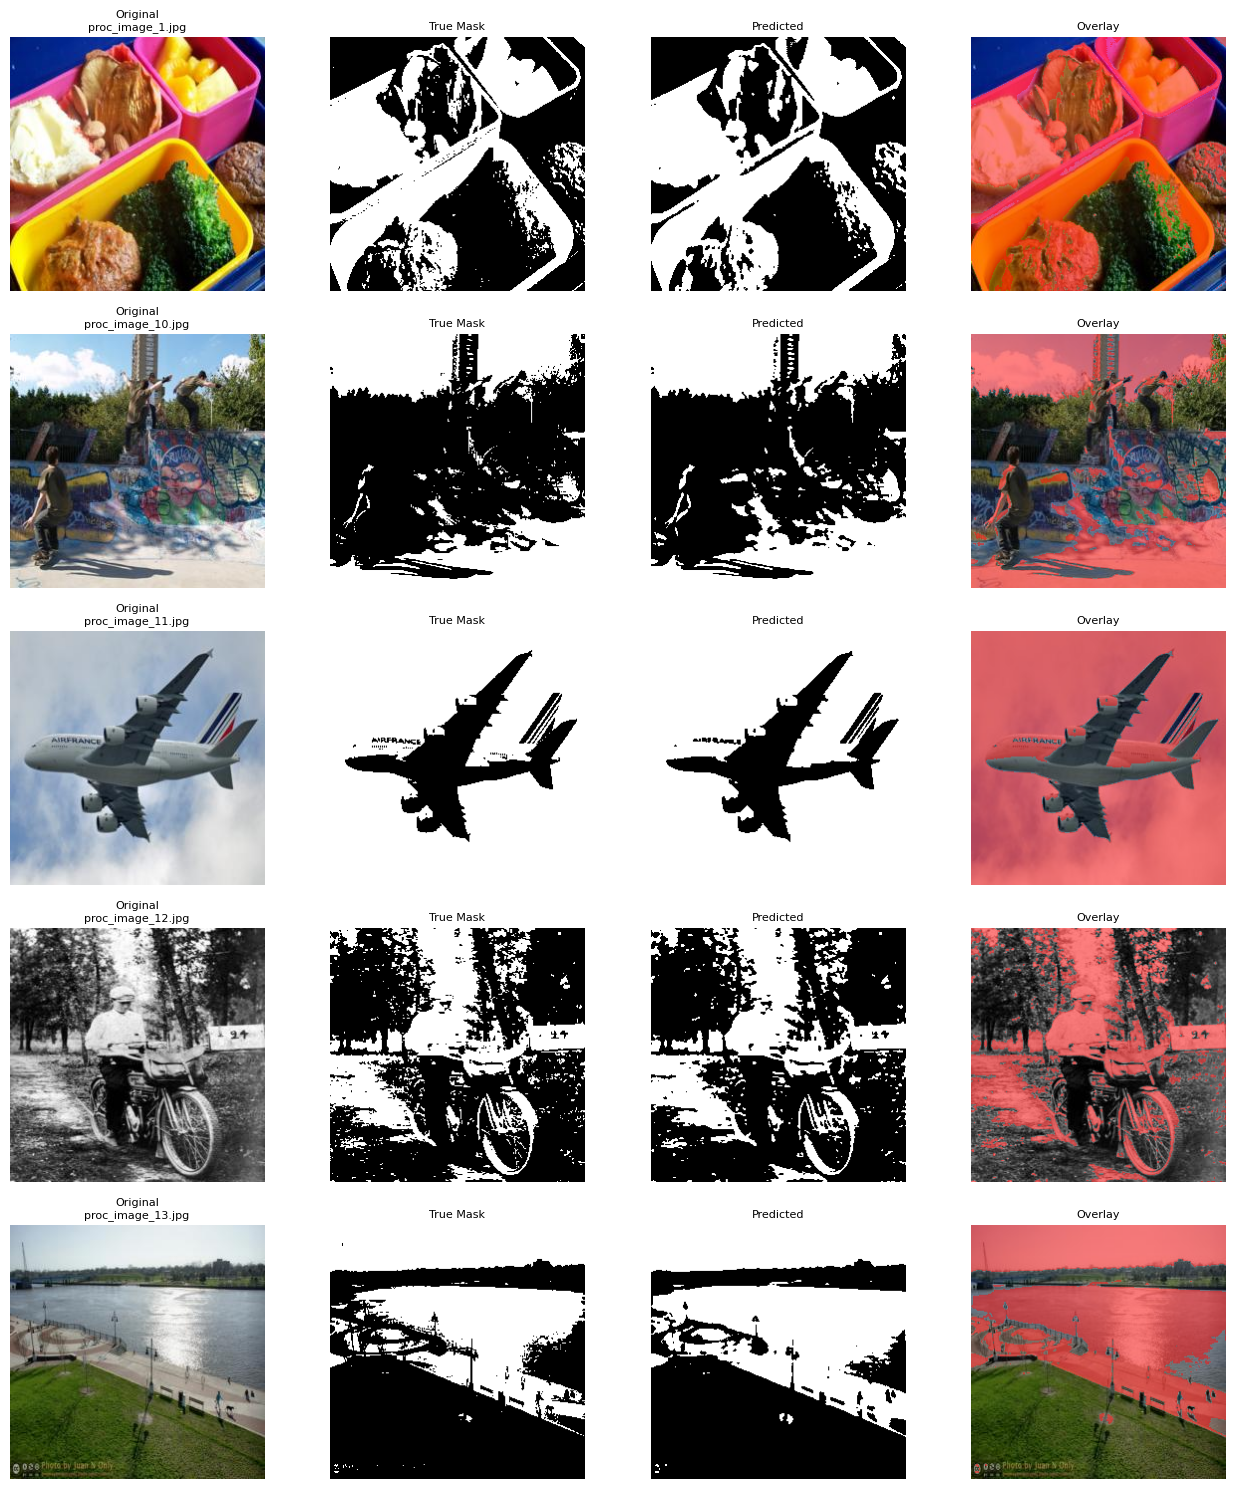

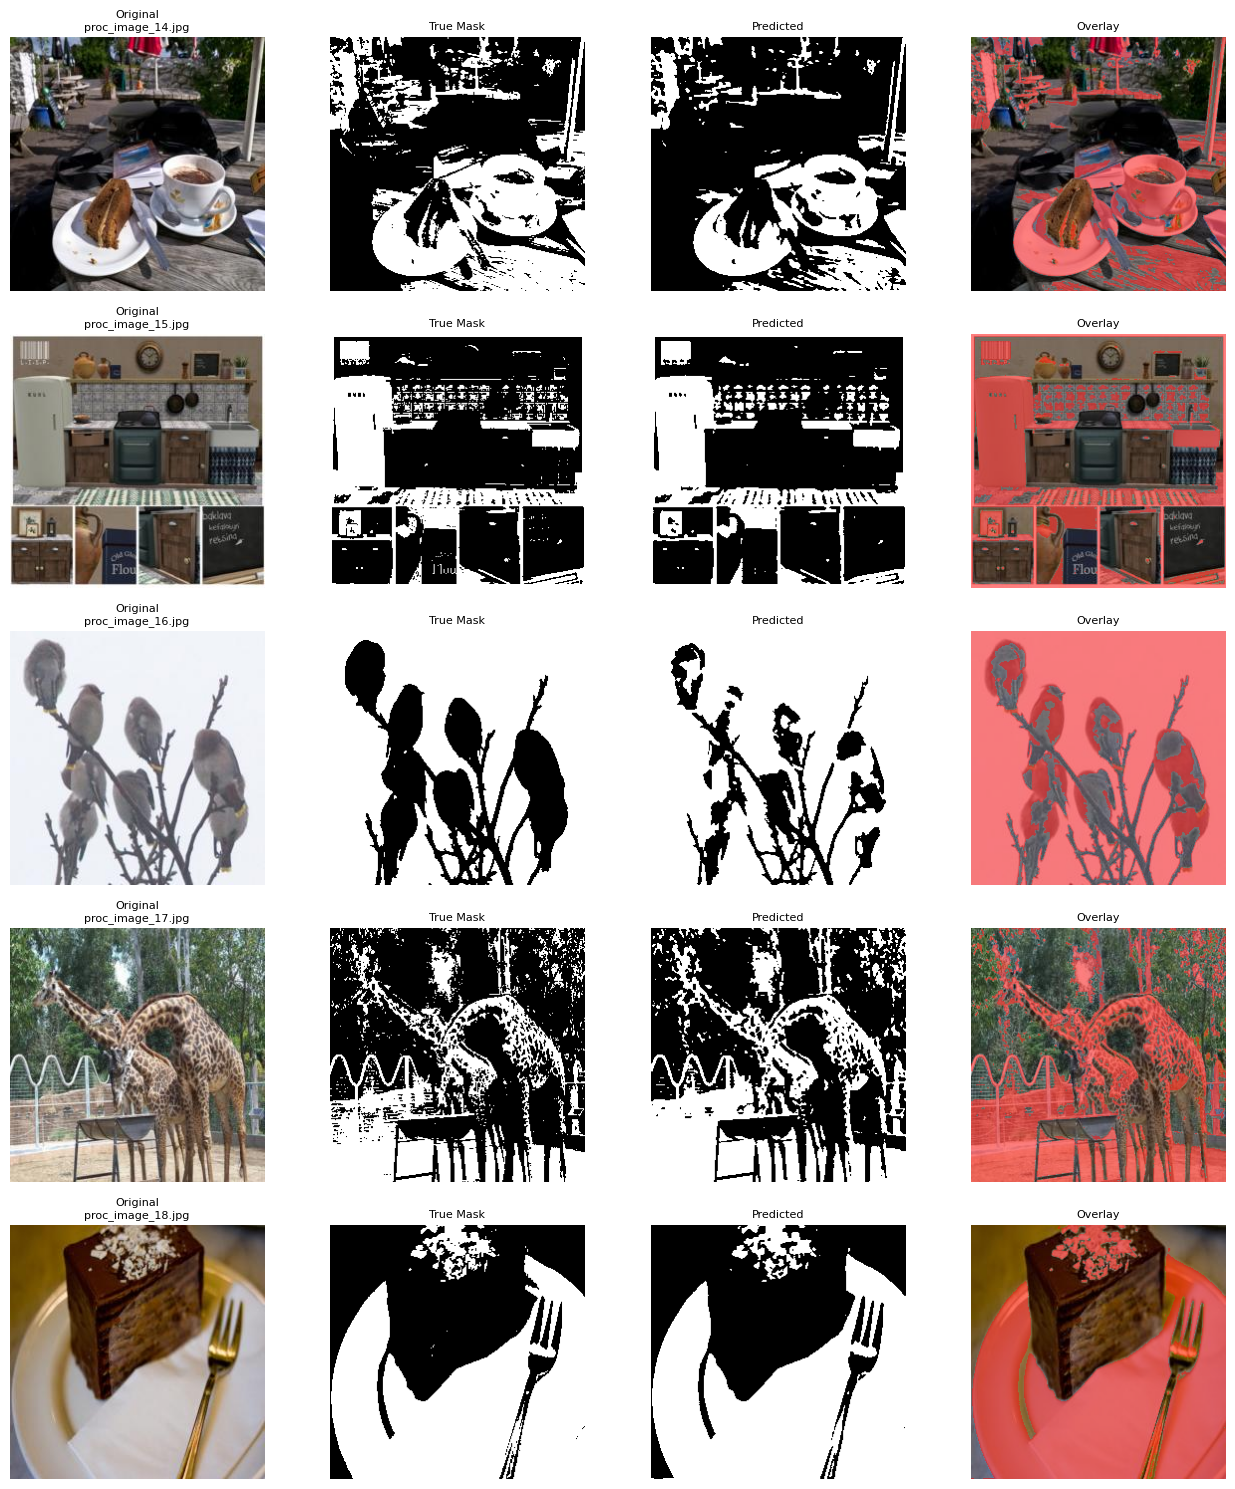

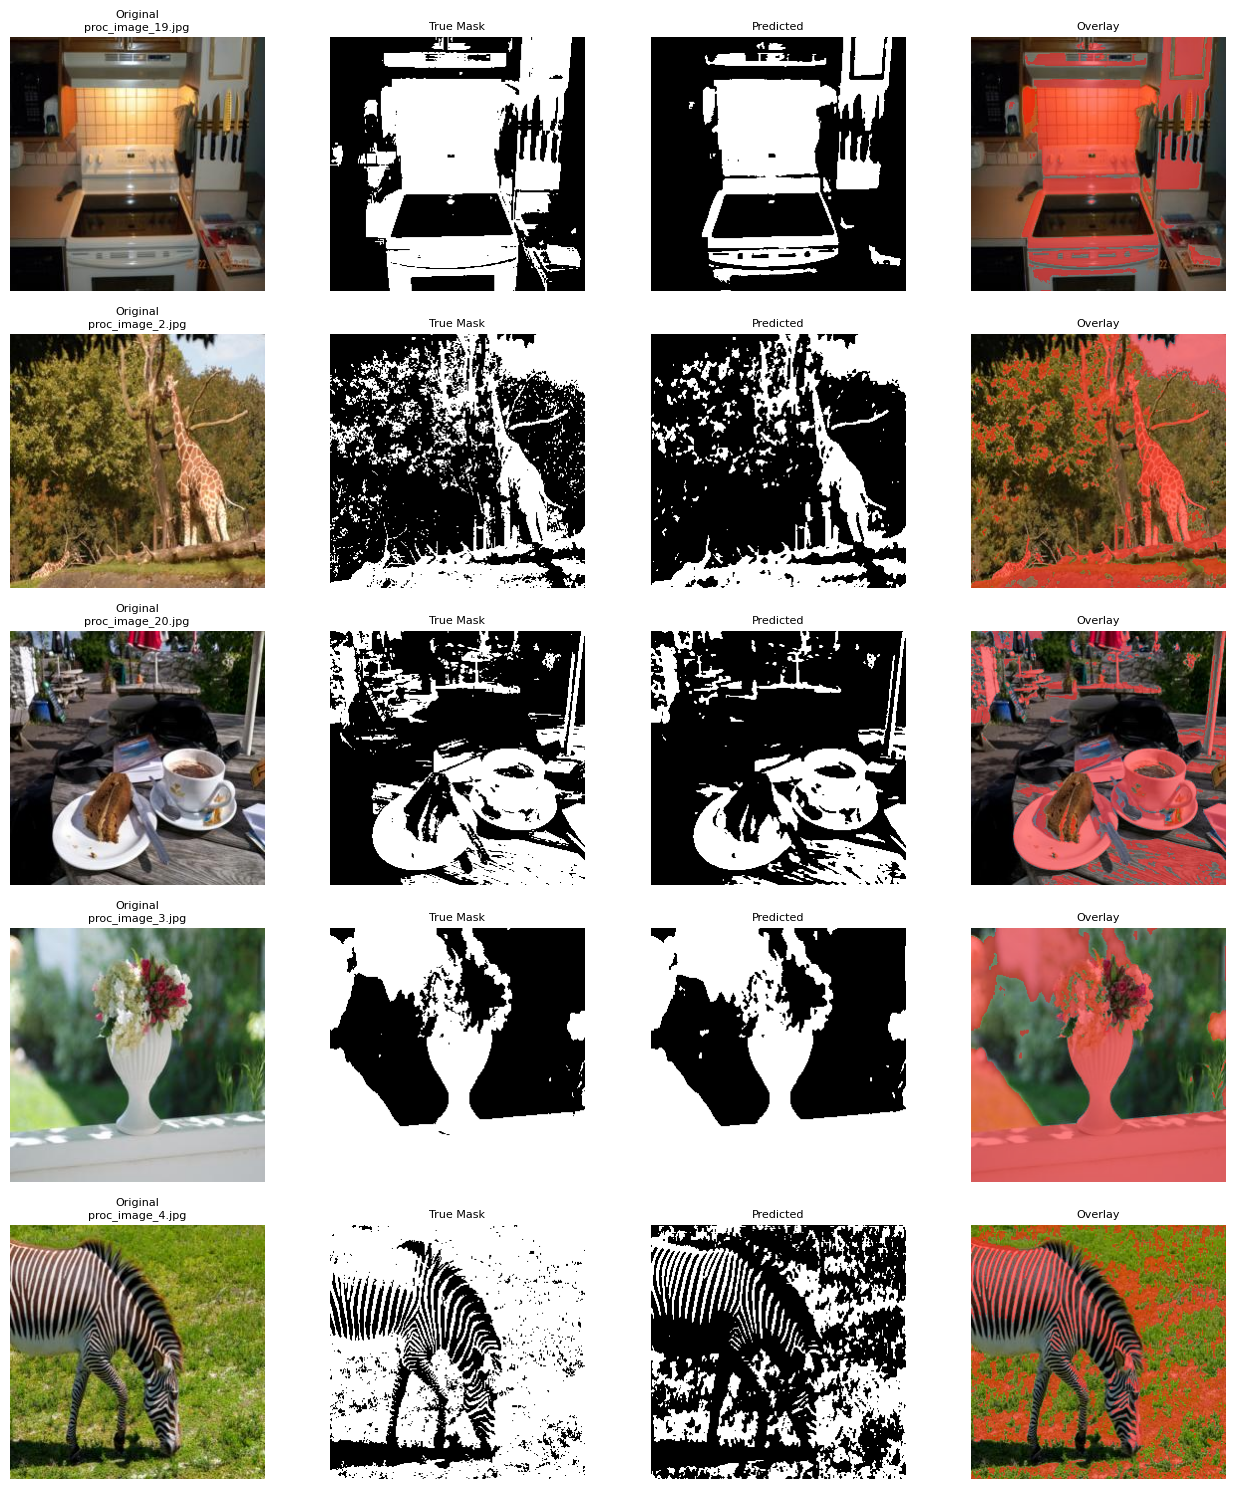

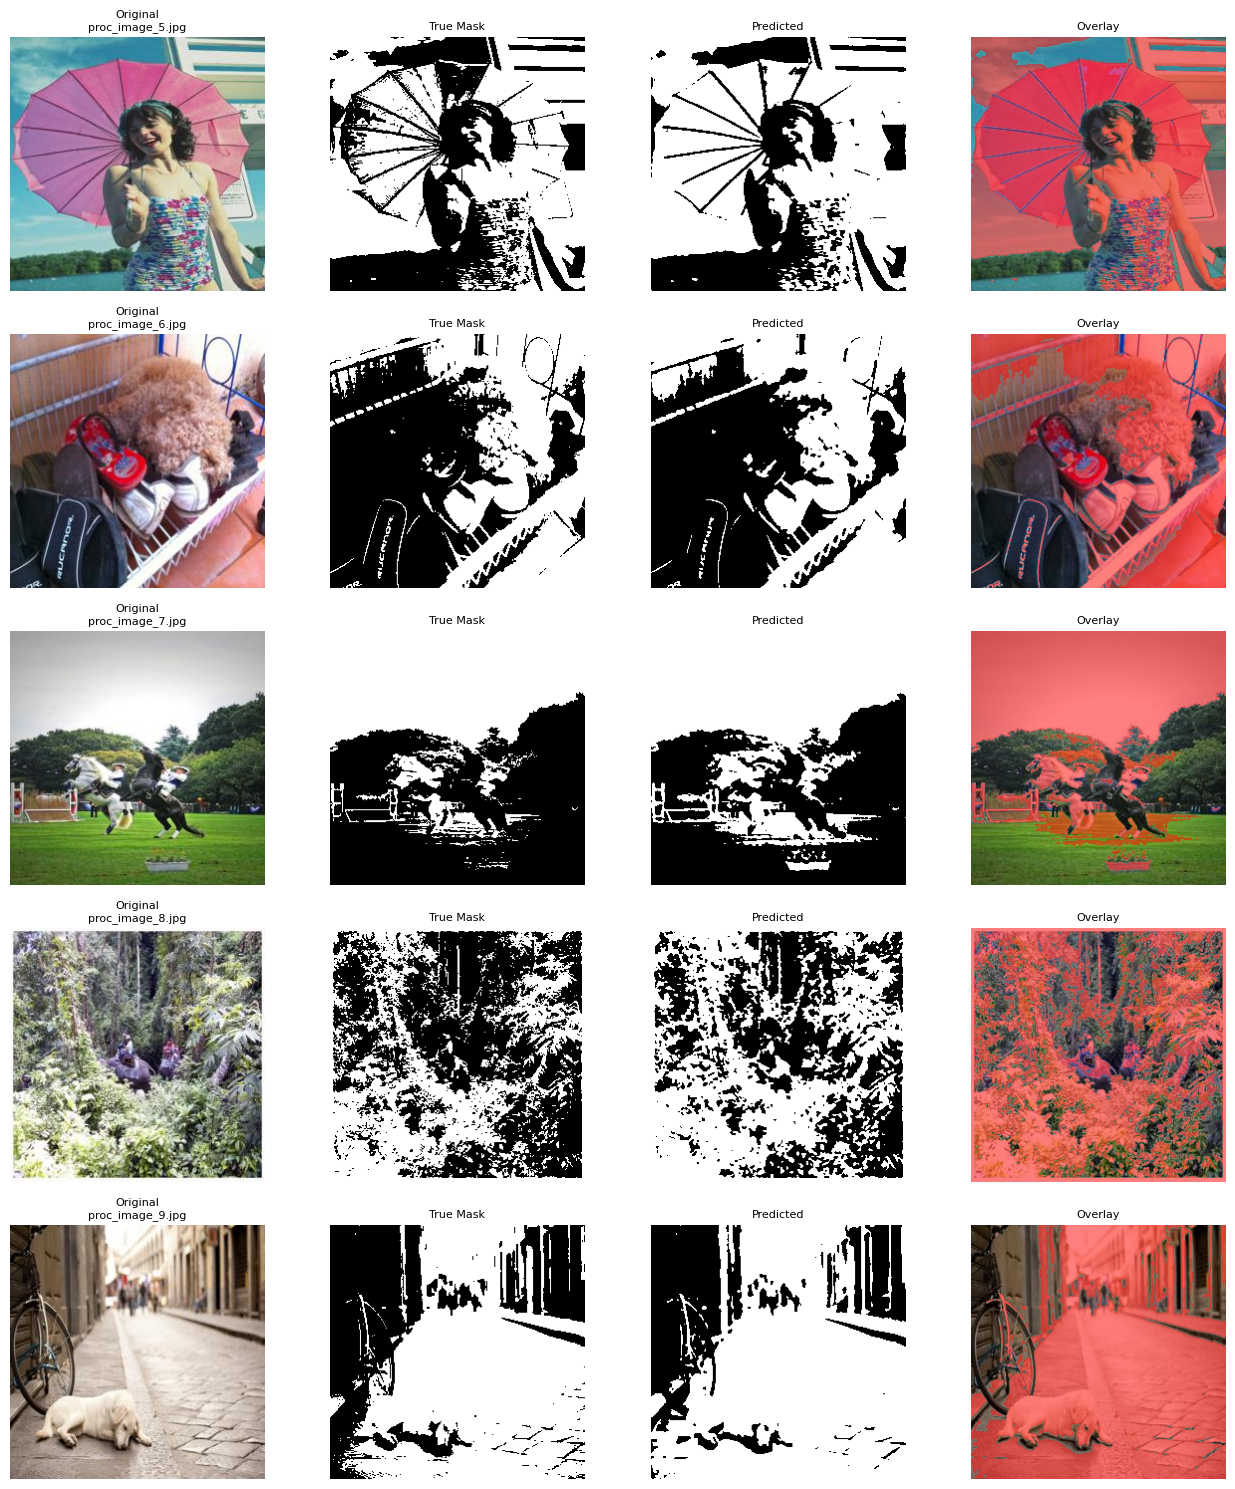

In [9]:
# SHOW: combined 4-panel grid per image, displayed in batches of 5 images per figure
from pathlib import Path
import torch
import torchvision.transforms as T
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn, torch.nn.functional as F
import random

# -------------- Adjust these if needed --------------
IMG_SIZE = 256
BATCH_SIZE = 5        # how many images to show per figure (rows per figure)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PROCESSED_DIR = Path("processed_20")
MASK_DIR = Path("processed_masks")
MODEL_PATH = "best_model.pth"
# ----------------------------------------------------

# --- small UNet definition (must match training model) ---
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
        )
    def forward(self,x): return self.net(x)

class Down(nn.Module):
    def __init__(self,in_c,out_c):
        super().__init__(); self.net = nn.Sequential(nn.MaxPool2d(2), DoubleConv(in_c,out_c))
    def forward(self,x): return self.net(x)

class Up(nn.Module):
    def __init__(self,in_c,out_c):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_c,out_c,2,stride=2)
        self.conv = DoubleConv(in_c,out_c)
    def forward(self,x1,x2):
        x1 = self.up(x1)
        diffY = x2.size()[2] - x1.size()[2]; diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX//2, diffX-diffX//2, diffY//2, diffY-diffY//2])
        x = torch.cat([x2,x1], dim=1); return self.conv(x)

class UNetSmall(nn.Module):
    def __init__(self, n_channels=3, n_classes=1, base=16):
        super().__init__()
        self.inc = DoubleConv(n_channels, base)
        self.down1 = Down(base, base*2)
        self.down2 = Down(base*2, base*4)
        self.up1 = Up(base*4, base*2)
        self.up2 = Up(base*2, base)
        self.outc = nn.Conv2d(base, n_classes, 1)
    def forward(self,x):
        x1 = self.inc(x); x2 = self.down1(x1); x3 = self.down2(x2)
        x = self.up1(x3, x2); x = self.up2(x, x1); x = self.outc(x); return x

# --- load model ---
model = UNetSmall(n_channels=3, n_classes=1).to(DEVICE)
ckpt = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()

# --- helpers ---
def key_from_path(p):
    s = p.stem.lower()
    s = s.replace("proc_", "").replace("mask_", "").replace("processed_","").replace("image_","")
    s = s.replace("-", "_")
    return s

proc_list = sorted([p for p in PROCESSED_DIR.glob("*") if p.suffix.lower() in ('.jpg','.jpeg','.png')])
mask_list = sorted([p for p in MASK_DIR.glob("*") if p.suffix.lower() in ('.jpg','.jpeg','.png')])

# map and pair
proc_map = { key_from_path(p): p for p in proc_list }
mask_map = { key_from_path(p): p for p in mask_list }
common_keys = sorted(set(proc_map.keys()) & set(mask_map.keys()))
if len(common_keys) == 0:
    raise SystemExit("No paired processed images & masks found. Ensure processed_20/ and processed_masks/ exist.")

paired = [(proc_map[k], mask_map[k]) for k in common_keys]
print(f"Displaying {len(paired)} paired images (showing in batches of {BATCH_SIZE}).")

# predict helper
to_tensor = T.ToTensor()
def predict_mask_pil(img_pil):
    img = img_pil.resize((IMG_SIZE, IMG_SIZE)).convert("RGB")
    tensor = to_tensor(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        out = torch.sigmoid(model(tensor))[0,0].cpu().numpy()
    mask = (out > 0.5).astype("uint8") * 255
    return Image.fromarray(mask)

# batching display
for batch_start in range(0, len(paired), BATCH_SIZE):
    batch = paired[batch_start: batch_start + BATCH_SIZE]
    rows = len(batch); cols = 4
    fig, axes = plt.subplots(rows, cols, figsize=(cols*3.3, rows*3.0))
    if rows == 1:
        axes = np.expand_dims(axes, 0)  # make 2D for consistent indexing
    for i, (proc_p, mask_p) in enumerate(batch):
        # load images
        orig = Image.open(proc_p).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        true_mask = Image.open(mask_p).convert("L").resize((IMG_SIZE, IMG_SIZE))
        pred_mask = predict_mask_pil(orig)

        # create overlay: red where pred_mask
        mask_arr = np.array(pred_mask)
        overlay = np.zeros((IMG_SIZE, IMG_SIZE, 4), dtype=np.uint8)
        overlay[...,0] = 255                    # red channel
        overlay[...,3] = (mask_arr // 2)        # alpha (128 where mask 255)
        overlay_img = Image.fromarray(overlay, mode="RGBA")
        blended = Image.alpha_composite(orig.convert("RGBA"), overlay_img)

        # plot 4 panels: Original | True Mask | Pred Mask | Overlay
        ax0 = axes[i, 0]
        ax1 = axes[i, 1]
        ax2 = axes[i, 2]
        ax3 = axes[i, 3]

        ax0.imshow(orig); ax0.set_title("Original\n" + proc_p.name, fontsize=8); ax0.axis("off")
        ax1.imshow(true_mask, cmap="gray"); ax1.set_title("True Mask", fontsize=8); ax1.axis("off")
        ax2.imshow(pred_mask, cmap="gray"); ax2.set_title("Predicted", fontsize=8); ax2.axis("off")
        ax3.imshow(blended); ax3.set_title("Overlay", fontsize=8); ax3.axis("off")

    plt.tight_layout()
    plt.show()
